- https://github.com/MoonshotAI/Kimi-K2.5/blob/master/tech_report.pdf
    - https://www.kimi.com/blog/kimi-k2-5.html
    - https://www.zhihu.com/question/1999487395494588876/answer/2000362433332660070

In [4]:
from IPython.display import Image

https://huggingface.co/moonshotai/Kimi-K2.5/blob/main/config.json
| 参数项目 | Kimi K2 | Kimi K2.5 |
| :--- | :--- | :--- |
| **Architecture (架构)** | Mixture-of-Experts (MoE) | Mixture-of-Experts (MoE) |
| **Total Parameters (总参数量)** | 1T | 1T |
| **Activated Parameters (激活参数量)** | 32B | 32B |
| **Number of Layers (层数)** | 61 (含 Dense layer) | 61 (含 Dense layer) |
| **Number of Dense Layers (稠密层数)** | 1 | 1 |
| **Attention Hidden Dimension (注意力隐层维度)** | 7168 | 7168 |
| **MoE Hidden Dimension (MoE 隐层维度)** | 2048 (per Expert) | 2048 (per Expert) |
| **Number of Attention Heads (注意力头数)** | 64 | 64 |
| **Number of Experts (专家总数)** | 384 | 384 |
| **Selected Experts per Token (每 Token 激活专家数)** | 8 | 8 |
| **Number of Shared Experts (共享专家数)** | 1 | 1 |
| **Vocabulary Size (词表大小)** | 160K | 160K |
| **Context Length (上下文长度)** | 256K | 256K |
| **Attention Mechanism (注意力机制)** | MLA | MLA |
| **Activation Function (激活函数)** | SwiGLU | SwiGLU |
| **Vision Encoder (视觉编码器)** | - | **MoonViT** |
| **Parameters of Vision Encoder (视觉编码器参数)** | - | **400M** |

- k1.5: SCALING REINFORCEMENT LEARNING WITH LLMS
- k2: OPEN AGENTIC INTELLIGENCE
- k2.5: VISUAL AGENTIC INTELLIGENCE

### visual & multi modality

- 传统的 Late-fusion（后期融合）策略往往导致视觉和文本能力的此消彼长，无法做到真正的"原生多模态"。
- 从预训练阶段就开始的文本-视觉联合优化（Joint Optimization）
    - MoonViT-3D 视觉编码器
    - 通过 NaViT (Native Resolution ViT) Packing 和 Spatiotemporal Volume 将空间和时间维度统一为 1D 序列的架构设计
        - 支持原生分辨率输入，避免了图像的裁剪和缩放
        - 时空联合处理（Spatiotemporal Volume），将连续帧打包处理，并通过 Temporal Pooling 实现 4x 的时间压缩，从而极大地扩展了视频理解的上下文窗口

#### MoonViT-3D

- 不仅继承了 NaViT 的原生分辨率处理能力，还针对视频理解引入了时空联合处理（Spatiotemporal Volume）和时序池化（Temporal Pooling）
- Example: Encoding a Video Clip
    - input data: `[T=4, H=224, W=224, C=3]`
    - Patching: 每个 224x224 的帧被切分为 14x14 的 Patches。4 * 224/16 * 224/16 = 1024 patches
    - Packing (NaViT): NaViT 策略将这 1024 个 Patches 展平并打包进一个长序列。如果输入是不同分辨率的图片，它们也会被打包在同一个 Sequence ID 中，通过 Attention Mask 区分。
        - 在 Self-Attention 计算时，引入一个 Block Diagonal Mask（块对角掩码）。这个掩码确保图片 A 的 patch 只能看到图片 A 的 patch，图片 B 只能看到图片 B。
    - Spatiotemporal Volume: MoonViT-3D 将这 4 帧视为一个 Spatiotemporal Volume。它们共享同一个 Embedding 空间和 Transformer 权重，Attention 机制同时作用于空间和时间维度。
        - `Temporally averaged at the patch level`
        - $Token_{(x,y)}^{new} = \mathrm{Average}(Token_{(x,y)}^{frame1}, Token_{(x,y)}^{frame2}, Token_{(x,y)}^{frame3}, Token_{(x,y)}^{frame4})$
    - Temporal Pooling: 在输入 LLM 之前，模型对每组连续的 4 帧进行 Patch-level Averaging（或类似的聚合操作）。空间位置相同的 4 个 patch 被压缩为 1 个 token。
        - Final Output to MLP: `[1, 256, Hidden_Dim]`
- 位置编码：Transformer 架构本质上是"置换不变"（Permutation Invariant）的
    - qwen2.5-vl: MRoPE, qwen3-vl: interleaved MRoPE
    - `identical attention mechanism to operate seamlessly across both space and time`
        - Embedding 层必须包含区分空间 $(h,w)$ 和时间 $t$ 的信息
        - $m=f(t,h,w)$

#### `modeling_kimi_k25.py`

https://huggingface.co/moonshotai/Kimi-K2.5/blob/main/modeling_kimi_k25.py
- 图像被视为 $T=1$ 的视频，视频被视为 $T=4$ 的序列，共享同一套权重，通过 grid_thws 区分。
- Kimi K2.5 不使用传统的将图像 Resize 到固定正方形（如 $336 \times 336$）的方法，而是采用 NaViT 策略。
    - Native Resolution (原生分辨率): 保持图像的原始纵横比，仅调整尺寸以适应 Patch Grid。
    - Patch Packing (Patch 打包): 将来自不同图像（或视频帧）的 Patch 序列拼接（Concatenate）在一起，形成一个长序列输入给 Transformer，通过 Attention Mask 实现样本间的隔离。
    - 3D Extension: 对视频，将连续的 $T$ 帧视为一个 "3D Volume" 进行联合处理。
- 输入定义
    - 输入为一个视觉数据块（Image 或 Video Chunk）。输入张量：$X_{raw} \in \mathbb{R}^{T \times H_{in} \times W_{in} \times 3}$
        - 对于图像：$T=1$。
        - 对于视频：根据报告，连续帧被分组，$T=4$ (通常配置) 。代码中由 temporal_merge_kernel_size 控制分块。
- NaViT Resize & Padding
    - 计算逻辑：保持纵横比，使得总 Token 数不超过限制，且 $H, W$ 能被 patch_size 整除。
    - Padding：在右侧和下侧填充 0，使其尺寸完全匹配 Patch 网格。
    - 结果：$X_{resized} \in \mathbb{R}^{T \times H \times W \times 3}$
- Patchify (切片): 代码 navit_patchify 将像素展平为 Patch 序列。给定 Patch 大小 $P$ (通常为 14 )，生成的 Patch 序列长度为 $L = T \times \frac{H}{P} \times \frac{W}{P}$。
    - $X_{patches} \in \mathbb{R}^{L \times (P^2 \cdot 3)}$ （pixel-level）
- Vision Encoder: MoonViT-3D, Encoder 是一个基于 SigLIP 初始化并升级的 3D ViT。输入是展平的 Patches，输出是深层特征。
    - MoonVision3dPatchEmbed 不同于传统的 Linear Projection，这里使用了 3D 位置编码逻辑，但通过 Conv2d 实现 Patch 提取。
        - 投影 (Projection): $E_{patch} = \text{Conv2d}(X_{resized}, \text{kernel}=P, \text{stride}=P)$
            - $(B, 3, H, W)$, $P=14$
            - `nn.Conv2d(in_channels=3, out_channels=1152, kernel_size=14, stride=14)`
                - 卷积核大小和步长都等于 Patch Size ($14$)，这意味着卷积在图像上无重叠地滑动。
                - 输入: $(B, 3, H, W)$, 输出 (Feature Map): $(B, 1152, \frac{H}{14}, \frac{W}{14})$
            - $(B, 1152, \frac{H}{14}, \frac{W}{14}) \rightarrow (B, L, 1152)$
                - $L = (\frac{H}{14}) \times (\frac{W}{14}) = \frac{H \times W}{196}$
        - 输出 Reshape 后为 $Z_0 \in \mathbb{R}^{L \times D_{model}}$，其中 $D_{model}$ 是 hidden size (如 1152)。
    - 3D 位置编码 (Positional Embedding): $\text{Pos}(t, h, w) = \text{Pos}_{space}(h, w) + \text{Pos}_{time}(t)$
        - 空间部分：基于可学习的 2D Embedding，如果输入分辨率变化，通过插值 (interpolate) 调整大小。
        - 时间部分：仅当 $T > 1$ (视频) 时，叠加时间 Embedding。最终输入：$Z_{input} = Z_0 + \text{Pos}(t, h, w)$
- Transformer Blocks & RoPE 2D
    - 同于 NLP 中的 1D RoPE，这里根据 grid_thws 计算 $(h, w)$ 坐标的频率：$\text{RoPE}(q, k, h, w) = \text{ApplyRotary}(q, k, \text{Freqs}_{h}, \text{Freqs}_{w})$
    - Patch Packing (多个不同分辨率图像拼在一个 batch) 的情况下，模型仍能感知每个 Patch 的绝对 2D 空间位置。
- 时序压缩与特征投影 (Temporal Compression & Projection)
    - 时序池化 (Temporal Pooling): 在 Encoder 输出特征 $Z_{enc} \in \mathbb{R}^{L \times D}$ 后，模型执行 "4x temporal compression"。
    - 假设一个 Chunk 包含 $T$ 帧 (例如 4 帧)，空间网格为 $h \times w$：
        - Reshape: 将线性序列恢复为 3D 结构：$Z_{view} \in \mathbb{R}^{T \times h \times w \times D}$
        - Mean Pooling: 在时间维度 $T$ 上取平均：$Z_{pooled} = \frac{1}{T} \sum_{t=1}^{T} Z_{view}[t, :, :, :]$
        - 输出形状变为 $\mathbb{R}^{1 \times h \times w \times D}$。这意味着 4 帧视频被压缩成了 1 帧的特征表示，极大降低了 LLM 的 Context 占用。
- 空间合并与 MLP 投影 (Spatial Merge & Projector)
    - 将 $2 \times 2$ 的相邻 Patch 特征拼接：$Z_{spatial} \in \mathbb{R}^{\frac{h}{2} \times \frac{w}{2} \times (4 \cdot D)}$
    - mlp projection: $Z_{llm} = \text{MLP}(Z_{spatial})$ 最终输出维度映射到 LLM 的 Hidden Size (如 7168)。

#### Joint Optimization (Unified Representation)

> jointly vs. independently
- Vision-Text 混合比例对模型性能的影响: tab1/fig9
- Kimi K2.5 在预训练阶段就采用了“联合预训练”策略，即在早期就开始混合文本和视觉数据。这使得模型在底层已经建立了强大的视觉-文本对齐（Vision-Text Alignment）。因此，通过文本 SFT 习得的推理和工具使用能力，可以自然地“迁移”并泛化到视觉模态上

#### zero-vision SFT: 代码即视觉

> 不需要昂贵且难以标注的高质量多模态推理数据（CoT），仅利用丰富的文本数据即可解决多模态 RL 的冷启动问题 。
- An observation is that high-quality text SFT data are relatively **abundant and diverse**. We propose a novel approach, zero-vision SFT, that uses **only text SFT** data to activate the visual, agentic capabilities during post-training.
- In this approach, all image manipulations are proxied through **programmatic operations in IPython**, effectively serving as a generalization of traditional vision tool-use. This "zero-vision" activation enables diverse reasoning behaviors, including pixel-level operations such as **object size estimation via binarization and counting**, and **generalizes to visually grounded tasks such as object localization, counting, and OCR.**
- 相比于稀缺且往往局限于简单操作（如裁剪、旋转）的视觉 SFT 数据，高质量的文本 SFT 数据非常丰富且多样。通过学习处理复杂的文本逻辑和代码任务，模型“举一反三”地激活了处理视觉信息的能力
    - 初步实验表明，如果在 SFT 阶段引入包含人工设计的视觉推理轨迹（Text-Vision SFT），模型的表现反而不如仅使用纯文本 SFT。这可能是因为现有的视觉 SFT 数据质量不高或多样性不足，反而限制了模型的泛化能力
    - 通过“零视觉 SFT”激活的模型，不仅能做基础的物体定位和 OCR，还能通过写代码进行像素级的推理（如通过二值化算法估算物体大小），展现出比传统视觉工具更灵活的能力

> 让 vision 直接对齐到 text 的 thinking 和 tooluse pattern 上。因为模型在预训练阶段已经将视觉 Token 和文本 Token 映射到了同一个 Embedding 空间，所以当模型学会了在文本中“先思考、再写代码、再解决问题”的模式后，这种模式会自动迁移到视觉任务中。
- 仅使用高质量的纯文本 SFT 数据就能激活视觉工具能力。
    - 通过将图像操作代理为 IPython 代码（如 `cv2.imread`），模型学会了视觉推理的逻辑。
- 什么样的数据和 Task 构成了 Zero-Vision SFT？
    - 模拟视觉输入： 并不真正加载图片，而是给出文字描述："假设变量 img 是一个 1024x1024 的 numpy 数组，代表一张包含红色圆形的图片"。
    - Task 1 (计数): "编写代码计算 img 中像素值 > 200 的区域连通域数量"。这教会模型使用 `cv2.connectedComponents`。
    - Task 2 (定位): "找到图像中心点坐标"。这教会模型 img.shape 的使用。
    - Task 3 (裁剪): "编写代码切出左上角 100x100 的区域"。这教会模型数组切片 `img[:100, :100]`。
- 这本质上是在训练模型把"视觉意图"翻译成"API 调用"的能力(agentic)。当真正推理时，真实的视觉 Encoder 提供了 Embedding，而 Zero-Vision SFT 训练出的 Policy 负责调度工具处理这些 Embedding（或其解码结果）。

- Figure 12
    - Binarization (Binarization Master)，difference map
    - BFS (code as vision tool)
        - 对图片进行二值化（0-1矩阵）， 设置起点和终点，
    - Draw point，path
- code as (general) vision tool,  `ipython`(kimi web) as the env
    - 像素级分析
    - `from PIL import Image, ImageDraw, ImageFont`

#### Joint Multimodal RL

$$
\max_{\pi_\theta} \mathbb{E}_{x \sim \mathcal{D}, y \sim \pi_\theta(y|x)} \left[ r_\phi(x, y) \right] - \beta \mathbb{D}_{\text{KL}} \left[ \pi_\theta(y \mid x) \parallel \pi_{\text{ref}}(y \mid x) \right],
$$

$$
L_{RL}(\theta) = \mathbb{E}_{x \sim \mathcal{D}} \left[ \frac{1}{N} \sum_{j=1}^{K} \sum_{i=1}^{|y_j|} \text{Clip} \left( \frac{\pi_{\theta}(y_i^j | x, y_{0:i}^j)}{\pi_{\text{old}}(y_i^j | x, y_{0:i}^j)}, \alpha, \beta \right) (r(x, y^j) - \bar{r}(x)) - \tau \left( \log \frac{\pi_{\theta}(y_i^j | x, y_{0:i}^j)}{\pi_{\text{old}}(y_i^j | x, y_{0:i}^j)} \right)^2 \right]
$$
- 组内相对优势（Group Relative)、无 Critic 网络（Policy-only）、带有特殊正则化项 的策略优化算法。
- 优势函数 (Advantage Function): $(r(x, y^j) - \bar{r}(x))$
    - $A_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ ($V(s)$ critic model, value function)
- 特殊的截断机制 (Clipping / Gradient Masking)
    - 如果新旧策略的概率比率（Log-ratio）超出了 $[\alpha, \beta]$ 的范围，该 Token 的梯度会被直接置零（zeroed out），不再更新。这防止了策略在单次更新中发生过大的漂移（Off-policy drift）。
    - regardless of the sign of the advantages.
- 正则这一项：$k2$ estimator，squared log-ratio

- 除了传统的 Rule-based Reward，还引入了生成式奖励模型（Generative Reward Models, GRM）。
- token-efficient RL: the toggle algorithm，在 Test-time Scaling 中兼顾效果与效率
$$
\tilde{r}(x, y) = \begin{cases} 
r(x, y) \cdot \mathbb{I}\{|y| < \text{budget}(x)\} & \text{if } \lfloor t/m \rfloor \pmod 2 = 0 \quad (\text{Phase 0: Budget}) \\
r(x, y) & \text{if } \lfloor t/m \rfloor \pmod 2 = 1 \quad (\text{Phase 1: Scale})
\end{cases}
$$
    - $m$ 超参数，控制两个阶段切换的频率（例如每 $m=100$ 个训练步切换一次）。它决定了模型在"学会省 Token"和"学会扩充思考"之间摆动的节奏。
    - $\text{budget}(x)$ 问题相关（Problem-dependent）的动态预算。
        - $\text{budget}(x) = \text{Percentile}(\{|y_j| \mid r(x, y_j) = 1, j = 1 \dots K\}, \rho)$
        - $\rho$ (Percentile Threshold): 分位数参数（例如 $\rho=0.75$, $\rho=0.9$)
            - 从所有做对题目 $r=1$, 的采样回复中，取第 $\rho$ 分位的长度作为预算上限。这意味着模型必须尝试向"更精简但正确"的方向优化，而不是无限制地通过堆砌 Token 来换取正确率。
- 视觉 RL 训练反向提升了纯文本任务的性能（如 MMLU-Pro 和 GPQA），验证了模态间的知识迁移。

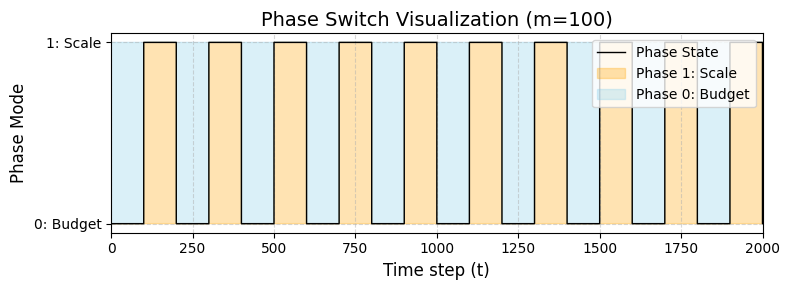

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 设置参数
m = 100
t_start = 0
t_end = 10000  # 根据要求 0 - 10000

# 生成 t 的序列
t = np.arange(t_start, t_end)

# 2. 计算 Phase
# floor(t/m) % 2
# 0 代表 Phase 0 (Budget), 1 代表 Phase 1 (Scale)
phases = np.floor(t / m).astype(int) % 2

# 3. 绘图可视化
plt.figure(figsize=(8, 3))

# 使用 step 图来展示离散的 0/1 状态切换
plt.plot(t, phases, drawstyle='steps-post', color='black', linewidth=1, label='Phase State')

# 填充颜色以区分 Phase
# Phase 1 (Scale) 区域填充为橙色
plt.fill_between(t, 0, phases, step='post', color='orange', alpha=0.3, label='Phase 1: Scale')
# Phase 0 (Budget) 区域填充为蓝色 (即 phases 为 0 的部分，也就是背景)
plt.fill_between(t, phases, 1, step='post', color='skyblue', alpha=0.3, label='Phase 0: Budget')

# 设置图表细节
plt.title(f'Phase Switch Visualization (m={m})', fontsize=14)
plt.xlabel('Time step (t)', fontsize=12)
plt.ylabel('Phase Mode', fontsize=12)
plt.yticks([0, 1], ['0: Budget', '1: Scale'])
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# 为了看清细节，限制 x 轴范围展示前 2000 步 (可选)
# 如果展示全全长 10000，密度会非常高，像条形码
plt.xlim(0, 2000) 

plt.tight_layout()

### agent swarm

- features
    - 非预定义的 mas，
    - parallel
        - task decomposition，delegate different sub-agents
- 两个理解的角度
    - context engineering
        - isolate context，more total context
    - speed
        - 任务越复杂，压缩的时间越多；

$$
R_t = \lambda_{\text{aux}}(e) \cdot \underbrace{r_{\text{parallel}}}_{\text{instantiation reward}} + (1 - \lambda_{\text{aux}}(e)) \cdot \underbrace{(\mathbb{I}[\text{success}] \cdot Q(\tau))}_{\text{task-level outcome}}
$$

- PARL：Parallel Agent Reinforcement Learning
    - orchestrator spawn agents natively
        - K2.5 introduces Agent Swarm, a self-directed parallel agent orchestration framework that dynamically decomposes complex tasks into **heterogeneous sub-problems** and executes them concurrently.
        - 在传统的并行计算或简单 Agent 系统中，任务拆分往往是同构的（Homogeneous）。例如，把一本 100 页的书拆成 10 份，让 10 个相同的 Agent 去读，这是“同构并行”。
    - 仅优化 Orchestrator (编排器/Master Agent)。Sub-agents (子代理) 在训练期间是冻结 (Frozen) 的。
        - Orchestrator (Main Agent)：这是唯一进行梯度更新的部分。它的任务是学习"如何拆解问题"、"何时并行"以及"何时结束"。
        - Sub-agents (Frozen)：它们不参与参数更新。它们的角色类似于"环境工具"（Environment Tools）。Orchestrator 调用它们，它们返回结果，就像调用 Google Search API 一样。
    - 为了解决 "Credit Assignment Ambiguity"（信用分配歧义）和 "Training Instability"（训练不稳定性）。
    - "train the orchestrator using small-size subagents before transitioning to larger models"（先用小模型做子代理训练编排器，再迁移到大模型）。这意味着在训练阶段，Sub-agent 甚至可以是比 Orchestrator 更小的轻量级模型，以加快训练速度（Rollout 效率更高）。
- $\lambda_{\text{aux}}(e)$：初始化为 0.1，奖励并行，即奖励任务的分解，随着训练的进行，anneal to 0（在最后，只奖励 outcome）
    - 让整个 system 初始先学会分解和并行，一旦学会了 parallelize，再去学 optimize
    - 这种渐进式地 training，prevents serial collapse

$$
\text{CriticalSteps} = \sum_{t=1}^{T} \left( S_{\text{main}}^{(t)} + \max_{i} S_{\text{sub},i}^{(t)} \right)    
$$

- 不是所有的任务都适合并行；
    - 被训练何时并行，何时串行
- Critical Steps, a latency-oriented metric inspired by the critical path in parallel computation:
    - $S_{\text{main}}^{(t)}$ captures orchestration overhead,  
    - while $S_{\text{sub},i}^{(t)}$ reflects the slowest subagent at each stage. Under this metric, spawning more subtasks only helps if it shortens the critical path.
- 任务的总耗时 = Orchestrator（协调者）的串行开销 + 最耗时的那个 Sub-agent（子智能体）的执行步数。
    - $T$：任务被拆解的总轮次（Turns）或阶段。
    - 分解 master => sub-agents 的交互也是多轮的；
- `We use Critical Steps as the efficiency metric for the reward function.`
    - $
Q(\tau) \propto \frac{1}{\text{CriticalSteps}(\tau)} \quad \text{或者} \quad Q(\tau) = \text{BaseReward} - \text{Coefficient} \times \text{CriticalSteps}(\tau)
$

#### 场景 A：重型任务（并行收益 > 协调开销）

- 假设一个复杂任务总共包含 70 个工作步骤。
- 方案 1：串行执行（Sequential）
    - Orchestrator 思考与分配（假设 1 步，overhead/开销）。
    - 单智能体执行所有 70 个步骤。
    - critical steps：1 + 70 = 71
- 方案 2：并行执行（Parallel）
    - Orchestrator 拆解任务并生成 4 个子智能体（假设协调开销为 4 步，overhead/开销）。
    - 子智能体分配不均：Agent A (40步), Agent B (10步), Agent C (10步), Agent D (10步)。
    - 取子智能体中的最大值：$\max(40, 10, 10, 10)=40$
    - critical steps：4(Orchestrator) + 40(Max Sub-agent) = 44
- 44<71。在此场景下，Critical Steps 显著减少。RL 算法会给予模型正向奖励，鼓励其选择并行策略。

#### 场景 B：轻型任务（协调开销 > 并行收益）

假设一个简单任务总共只需要 4 个工作步骤。
- 方案 1：并行执行（Parallel）
    - Orchestrator 为了并行化，强行拆解任务给 4 个子智能体（协调开销假设为 4 步）。
    - 每个子智能体执行 1 步。
    - 取最大值：$\max(1,1,1,1)=1$
    - critical steps: 4+1=5
- 串行执行（Sequential）
    - Orchestrator 简单思考（1 步）。
    - 单智能体直接执行 4 步。
    - critical steps: 1+4=5

### infra

In [6]:
Image(url='https://github.com/eric-haibin-lin/verl-community/blob/main/docs/multi_turn.png?raw=true', width=800)

$$
\exp(\log\frac{\pi_\theta}{\pi_{ref}}), \exp(\log\frac{\pi_\theta}{\pi_{old}})
$$

- 所有 generated 的 tokens 都是 sample from $\pi_{old}$
    - 既然是 $\pi_{old}$ 生成的 token id，自然是高概率的；
    - mismatch 时，会导致 $\pi_{ref}(a_t')$ 异常得低；
- 不使用 "Token in Token out" 破坏了 RL 训练中的 Off-policy 数据一致性。

- 使用 NVIDIA H800 GPU 集群，节点间（32x）采用 $8 \times 400$ Gbps RoCE (RDMA over Converged Ethernet) 网络互联。
- Unified Agentic RL Env
    - 标准化接口: 采用类似 Gym 的接口，支持快速接入不同环境。
    - 异步协程架构 (Async Coroutine): 将每个 Agent 任务视为一个独立的异步协程。
        - Rollout Manager: 能够同时编排 100,000 个并发 Agent 任务，支持细粒度的控制（如 Partial Rollout）。
    - Token-in-Token-out 与纠偏: 这是一个 Inference Engine 和 Training Engine 的协同设计（Co-design）。为了解决训练与推理的偏差，Infra 层会记录推理时的 Log Probabilities，用于进行 mismatch correction。
    - LLM Gateway: 针对那些只能通过标准 API 访问的“黑盒环境”，通过一个代理服务（Gateway）来记录符合 RL 协议的数据，从黑盒中“榨取”优化空间。
- Env Pool（环境池）： 管理环境实例的资源池，每个任务从中获取带沙箱的环境实例 。
    - White-Box Env（白盒环境）
        - Agent 不仅能拿到结果，还能配合“推理引擎服务（Inference Engine Service）”获取底层的**Log Probabilities（对数概率）**等深层数据 。这些数据对于强化学习中修正“训练-推理偏差（Mismatch Correction）”至关重要 。
    - Black-Box Env
        - 这些环境只能通过标准的 LLM API 协议（比如发一段 JSON，回一段 JSON）来运行 。
        - Agent 和黑盒环境交互时，流量会经过 Gateway。Gateway 会把这些标准的请求和响应拦截下来，强制转换并记录为符合 K2.5 内部自定义协议的详细日志格式

### misc

- 图文多模态预训练时 NTP：不包括 visual embedding 的预测；
    - Kimi K2.5 的视觉部分（MoonViT-3D）输出的是连续的特征嵌入（Continuous Embeddings），而不是离散的 Token ID（Discrete Tokens） 。
- 预训练 sequence length
    - 不同的 sample 进行 packing（sample 1:3，sample 2：2）

$$
\text{Standard Lower Triangular} =
\begin{bmatrix}
1 & 0 & 0 & 0 & 0 \\
1 & 1 & 0 & 0 & 0 \\
1 & 1 & 1 & 0 & 0 \\
1 & 1 & 1 & 1 & 0 \\
1 & 1 & 1 & 1 & 1
\end{bmatrix}
\quad \rightarrow \quad
\text{Packed (Block Diagonal)} =
\begin{bmatrix}
\mathbf{1} & \mathbf{0} & \mathbf{0} & 0 & 0 \\
\mathbf{1} & \mathbf{1} & \mathbf{0} & 0 & 0 \\
\mathbf{1} & \mathbf{1} & \mathbf{1} & 0 & 0 \\
0 & 0 & 0 & \mathbf{1} & \mathbf{0} \\
0 & 0 & 0 & \mathbf{1} & \mathbf{1}
\end{bmatrix}
$$


- GRM
    - **自我批判（Self-Critique）**机制，即让模型自己作为“裁判”来评估自己生成的回复。（模型在生成回复后，会转换角色成为“批评者（Critic）”）
        - the model evaluates its own outputs
        - bootstrap K2 as a competent judge
        - K2 Actor（行动者）和 K2 Critic（批评者）本质上是同一个模型（Kimi K2），
    - Critic 不会对单一回复直接打分，而是对生成的多个回复（Candidate Responses）进行**成对比较（Pairwise Comparisons）**和排序。
    - 比较的依据是预设的评分标准（Rubrics），这些标准涵盖了从核心价值观到具体指令要求的多个维度 。